# Taller 04: Redes neuronales (CNN, Keras y Perceptrón)
**Palacios Yoichi, Proyecto Integrador (C7328)**

Reutiliza el material de clase (`Redes_neuronales_ss`, `CNN_TransferLearning`, `Keras_Clasificacion_binaria`, `Red_neuronal_con_Keras`, `Perceptrón`) y se ejecutó en local, con CPU.

1. **CNN** (PyTorch) sobre TrashNet, vidrio contra plástico: CNN desde cero, data augmentation, transfer learning con ResNet18 y Grad-CAM.
2. **Keras**: clasificación binaria con IMDB (sobreajuste, modelo pequeño, L2, Dropout) y MNIST con una red densa.
3. **Perceptrón**: funciones de activación, compuertas AND y OR, y el problema XOR.

In [1]:
import os, sys, time, random, urllib.request, zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

SEED = 123
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid")
IMG = os.path.abspath(os.path.join("..", "..", "..", "..", "Recursos", "Imágenes"))
os.makedirs(IMG, exist_ok=True)
def guardar(nombre):
    plt.savefig(os.path.join(IMG, f"Taller4_Palacios_{nombre}.png"), dpi=130, bbox_inches="tight")
RES = {}   # aquí se guardan las métricas para el resumen final
print(sys.version.split()[0], "| carpeta de figuras:", IMG)

3.12.10 | carpeta de figuras: C:\Users\Usuario\Documents\Portfolio\laptop\PI_wt_talleres\Recursos\Imágenes


# Parte 1. CNN con PyTorch (TrashNet: vidrio vs. plástico)

## 1.1 Entorno y datos
El dataset es TrashNet (versión `dataset-resized`, fotos de residuos de 384x512 px) [1]. Se usan solo dos clases: vidrio (0) y plástico (1), en escala de grises, con la partición estratificada 70/15/15 que hace `trash_dataset.py` (semilla 42, la de la clase).

In [2]:
import torch, torch.nn as nn, torchvision, torchvision.transforms as T, torchvision.models as models
from torch.utils.data import DataLoader
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| device:", device)

DATA_DIR = "_datos/dataset-resized"
if not os.path.isdir(DATA_DIR):
    os.makedirs("_datos", exist_ok=True)
    url = "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip"
    urllib.request.urlretrieve(url, "_datos/dataset-resized.zip")
    with zipfile.ZipFile("_datos/dataset-resized.zip") as z:
        z.extractall("_datos")
for c in ["glass", "plastic"]:
    print(c, len(os.listdir(os.path.join(DATA_DIR, c))), "imágenes")

torch 2.14.1+cpu | torchvision 0.29.1+cpu | device: cpu
glass 501 imágenes
plastic 482 imágenes


In [3]:
from trash_dataset import TrashDataset
# Para que la CNN corra en CPU en pocos minutos, se reduce 384x512 a 144x192 (misma proporción 3:4)
SIZE = (144, 192)
transform_basic = T.Compose([T.Resize(SIZE), T.ToTensor()])
train_dataset = TrashDataset(DATA_DIR, "train", transform_basic)
val_dataset = TrashDataset(DATA_DIR, "val", transform_basic)
test_dataset = TrashDataset(DATA_DIR, "test", transform_basic)
print("train / val / test:", len(train_dataset), len(val_dataset), len(test_dataset))
for nombre, ds in [("train", train_dataset), ("val", val_dataset), ("test", test_dataset)]:
    labels = [l for _, l in ds.samples]
    print(nombre, "vidrio:", labels.count(0), "plástico:", labels.count(1))

train / val / test: 687 147 149
train vidrio: 350 plástico: 337
val vidrio: 75 plástico: 72
test vidrio: 76 plástico: 73


## 1.2 Verificación visual

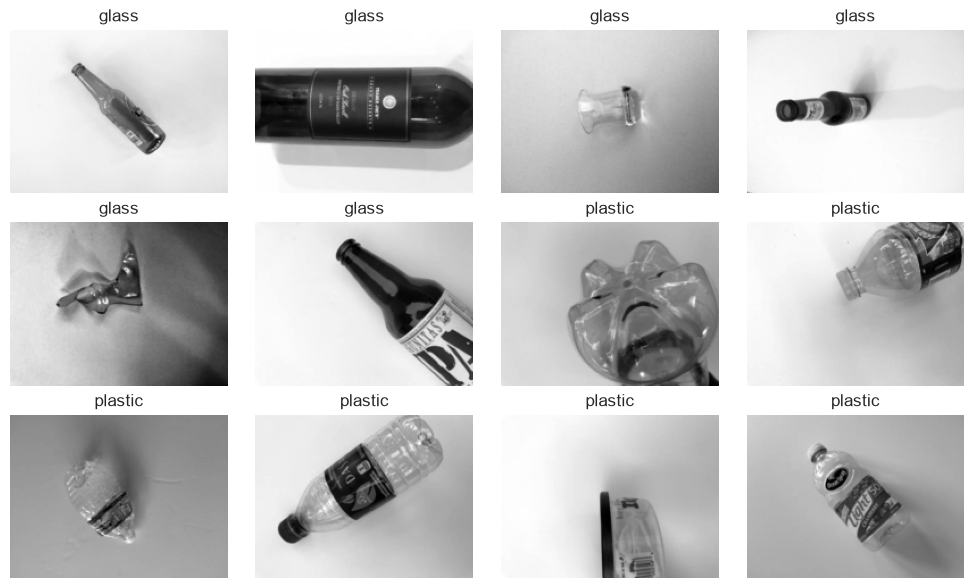

In [4]:
def show_glass_plastic(dataset):
    glass, plastic = [], []
    for i in range(len(dataset)):
        x, y = dataset[i]; y = int(y)
        if y == 0 and len(glass) < 6: glass.append((x, y))
        elif y == 1 and len(plastic) < 6: plastic.append((x, y))
        if len(glass) == 6 and len(plastic) == 6: break
    plt.figure(figsize=(10, 6))
    for i, (x, y) in enumerate(glass + plastic):
        plt.subplot(3, 4, i + 1); plt.imshow(x.squeeze(0), cmap="gray")
        plt.title(TrashDataset.classes[y]); plt.axis("off")
    plt.tight_layout()
show_glass_plastic(train_dataset); guardar("01_ejemplos_trashnet"); plt.show()

## 1.3 DataLoaders y funciones de entrenamiento y evaluación

In [5]:
batch_size = 64
def loader(ds, shuffle=False, bs=batch_size):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, generator=g)
train_loader, val_loader, test_loader = loader(train_dataset, True), loader(val_dataset), loader(test_dataset)

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, ps, pr = [], [], []
    for x, y in loader:
        x = x.to(device); y = y.to(device).long()
        probs = logits_to_probs(model(x))
        ys.append(y.cpu().numpy()); pr.append(probs.cpu().numpy()); ps.append((probs >= 0.5).long().cpu().numpy())
    y_true, y_pred, y_prob = map(np.concatenate, (ys, ps, pr))
    return accuracy_score(y_true, y_pred), roc_auc_score(y_true, y_prob), y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train(); losses = []
    for x, y in loader:
        x = x.to(device); y = y.to(device).long()
        optimizer.zero_grad(); loss = criterion(model(x), y); loss.backward(); optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

def entrenar(model, train_loader, val_loader, epochs, lr, params=None, etiqueta=""):
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(params if params is not None else model.parameters(), lr=lr)
    h = {"train_loss": [], "val_acc": [], "val_auc": []}
    for ep in range(1, epochs + 1):
        t = time.time()
        tl = train_one_epoch(model, train_loader, opt, criterion)
        va, vauc, *_ = evaluate(model, val_loader)
        h["train_loss"].append(tl); h["val_acc"].append(va); h["val_auc"].append(vauc)
        print(f"{etiqueta} época {ep:02d} | train_loss={tl:.4f} | val_acc={va:.4f} | val_auc={vauc:.4f} | {time.time()-t:.0f} s")
    return h

## 1.4 Modelo 1: CNN desde cero
Tres bloques Conv + ReLU (los dos primeros con MaxPool), `AdaptiveAvgPool` y una capa lineal, igual que en clase.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(SEED)
model_scratch = SimpleCNN(2).to(device)
print("Parámetros:", sum(p.numel() for p in model_scratch.parameters()))
t0 = time.time()
hist_scratch = entrenar(model_scratch, train_loader, val_loader, epochs=8, lr=1e-3, etiqueta="Scratch")
print("Tiempo total: %.0f s" % (time.time() - t0))

Parámetros: 23426


Scratch época 01 | train_loss=0.6983 | val_acc=0.5102 | val_auc=0.6602 | 8 s


Scratch época 02 | train_loss=0.6925 | val_acc=0.5102 | val_auc=0.6631 | 9 s


Scratch época 03 | train_loss=0.6910 | val_acc=0.5102 | val_auc=0.6780 | 8 s


Scratch época 04 | train_loss=0.6875 | val_acc=0.5374 | val_auc=0.6789 | 8 s


Scratch época 05 | train_loss=0.6819 | val_acc=0.6190 | val_auc=0.6867 | 9 s


Scratch época 06 | train_loss=0.6720 | val_acc=0.4694 | val_auc=0.6748 | 8 s


Scratch época 07 | train_loss=0.6736 | val_acc=0.6463 | val_auc=0.6900 | 9 s


Scratch época 08 | train_loss=0.6676 | val_acc=0.6531 | val_auc=0.6644 | 8 s
Tiempo total: 66 s


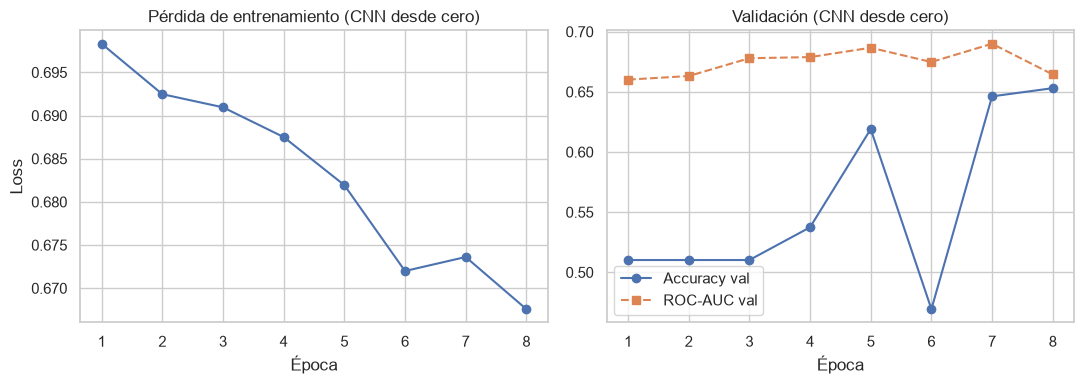

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 9), hist_scratch["train_loss"], "o-"); ax[0].set_title("Pérdida de entrenamiento (CNN desde cero)")
ax[0].set_xlabel("Época"); ax[0].set_ylabel("Loss")
ax[1].plot(range(1, 9), hist_scratch["val_acc"], "o-", label="Accuracy val"); ax[1].plot(range(1, 9), hist_scratch["val_auc"], "s--", label="ROC-AUC val")
ax[1].set_title("Validación (CNN desde cero)"); ax[1].set_xlabel("Época"); ax[1].legend()
plt.tight_layout(); guardar("02_curvas_cnn_scratch"); plt.show()

Test accuracy: 0.5436 | Test ROC-AUC: 0.6096

              precision    recall  f1-score   support

       glass     0.5526    0.5526    0.5526        76
     plastic     0.5342    0.5342    0.5342        73

    accuracy                         0.5436       149
   macro avg     0.5434    0.5434    0.5434       149
weighted avg     0.5436    0.5436    0.5436       149

[[42 34]
 [34 39]]


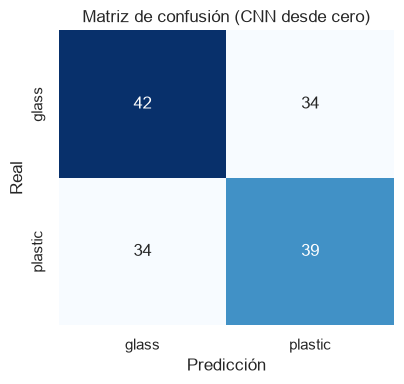

In [8]:
acc, auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
RES["CNN desde cero"] = (acc, auc)
print(f"Test accuracy: {acc:.4f} | Test ROC-AUC: {auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=TrashDataset.classes, digits=4))
cm = confusion_matrix(y_true, y_pred); print(cm)
def plot_cm(cm, titulo, nombre):
    plt.figure(figsize=(4.2, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=TrashDataset.classes, yticklabels=TrashDataset.classes, cbar=False)
    plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title(titulo); plt.tight_layout(); guardar(nombre); plt.show()
plot_cm(cm, "Matriz de confusión (CNN desde cero)", "03_confusion_cnn_scratch")

## 1.5 Data augmentation
Misma arquitectura, entrenando con rotaciones de hasta 10 grados y traslaciones de hasta 5 %, 6 épocas (como en clase).

In [9]:
transform_aug = T.Compose([T.Resize(SIZE), T.RandomRotation(10), T.RandomAffine(0, translate=(0.05, 0.05)), T.ToTensor()])
train_aug = TrashDataset(DATA_DIR, "train", transform_aug)
torch.manual_seed(SEED)
model_aug = SimpleCNN(2).to(device)
hist_aug = entrenar(model_aug, loader(train_aug, True), val_loader, epochs=6, lr=1e-3, etiqueta="Aug")
acc_a, auc_a, *_ = evaluate(model_aug, test_loader)
RES["CNN + augmentation"] = (acc_a, auc_a)
print(f"Sin augmentation | test_acc={RES['CNN desde cero'][0]:.4f} | test_auc={RES['CNN desde cero'][1]:.4f}")
print(f"Con augmentation | test_acc={acc_a:.4f} | test_auc={auc_a:.4f}")

Aug época 01 | train_loss=0.6984 | val_acc=0.5102 | val_auc=0.6480 | 8 s


Aug época 02 | train_loss=0.6930 | val_acc=0.5102 | val_auc=0.5594 | 8 s


Aug época 03 | train_loss=0.6928 | val_acc=0.5102 | val_auc=0.6880 | 8 s


Aug época 04 | train_loss=0.6920 | val_acc=0.5102 | val_auc=0.6896 | 8 s


Aug época 05 | train_loss=0.6920 | val_acc=0.5102 | val_auc=0.6798 | 7 s


Aug época 06 | train_loss=0.6903 | val_acc=0.6395 | val_auc=0.6969 | 8 s


Sin augmentation | test_acc=0.5436 | test_auc=0.6096
Con augmentation | test_acc=0.6040 | test_auc=0.6547


## 1.6 Transfer learning (ResNet18 preentrenada en ImageNet)
Se repite el canal gris en 3 canales y se reescala a 224x224. Etapa 1: backbone congelado, solo se entrena la capa final (4 épocas, lr 1e-3). Etapa 2: se descongela `layer4` y se afina (4 épocas, lr 1e-4).

In [10]:
tl_train = T.Compose([T.Resize((224, 224)), T.RandomRotation(10), T.RandomAffine(0, translate=(0.05, 0.05)), T.ToTensor(), T.Lambda(lambda x: x.repeat(3, 1, 1))])
tl_eval = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Lambda(lambda x: x.repeat(3, 1, 1))])
tr_tl = loader(TrashDataset(DATA_DIR, "train", tl_train), True, 32)
va_tl = loader(TrashDataset(DATA_DIR, "val", tl_eval), False, 32)
te_tl = loader(TrashDataset(DATA_DIR, "test", tl_eval), False, 32)

torch.manual_seed(SEED)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)
for n, p in resnet.named_parameters():
    p.requires_grad = n.startswith("fc")
print("Parámetros entrenables, etapa 1:", sum(p.numel() for p in resnet.parameters() if p.requires_grad))
t0 = time.time()
hist_tl1 = entrenar(resnet, tr_tl, va_tl, epochs=4, lr=1e-3, params=resnet.fc.parameters(), etiqueta="TL etapa 1")
print("Tiempo etapa 1: %.0f s" % (time.time() - t0))

Parámetros entrenables, etapa 1:

 1026


TL etapa 1 época 01 | train_loss=0.7110 | val_acc=0.6463 | val_auc=0.7050 | 26 s


TL etapa 1 época 02 | train_loss=0.5841 | val_acc=0.7347 | val_auc=0.8406 | 27 s


TL etapa 1 época 03 | train_loss=0.5270 | val_acc=0.7687 | val_auc=0.8752 | 27 s


TL etapa 1 época 04 | train_loss=0.4995 | val_acc=0.7687 | val_auc=0.8946 | 27 s
Tiempo etapa 1: 106 s


In [11]:
for n, p in resnet.named_parameters():
    if n.startswith("layer4") or n.startswith("fc"):
        p.requires_grad = True
trainable = [p for p in resnet.parameters() if p.requires_grad]
print("Parámetros entrenables, etapa 2:", sum(p.numel() for p in trainable))
t0 = time.time()
hist_tl2 = entrenar(resnet, tr_tl, va_tl, epochs=4, lr=1e-4, params=trainable, etiqueta="TL etapa 2")
print("Tiempo etapa 2: %.0f s" % (time.time() - t0))

Parámetros entrenables, etapa 2: 8394754


TL etapa 2 época 01 | train_loss=0.4228 | val_acc=0.8912 | val_auc=0.9472 | 37 s


TL etapa 2 época 02 | train_loss=0.1964 | val_acc=0.9048 | val_auc=0.9641 | 38 s


TL etapa 2 época 03 | train_loss=0.1153 | val_acc=0.8844 | val_auc=0.9637 | 38 s


TL etapa 2 época 04 | train_loss=0.0776 | val_acc=0.8912 | val_auc=0.9696 | 30 s
Tiempo etapa 2: 143 s


Transfer learning | test_acc=0.9060 | test_auc=0.9548

              precision    recall  f1-score   support

       glass     0.8780    0.9474    0.9114        76
     plastic     0.9403    0.8630    0.9000        73

    accuracy                         0.9060       149
   macro avg     0.9092    0.9052    0.9057       149
weighted avg     0.9085    0.9060    0.9058       149

[[72  4]
 [10 63]]


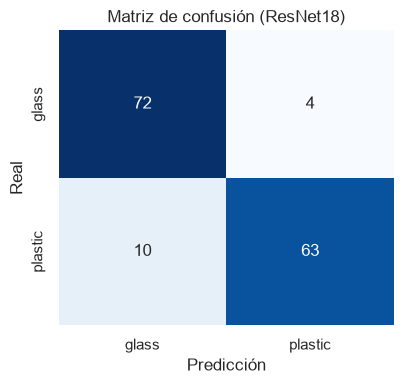

In [12]:
acc_t, auc_t, y_true_t, y_pred_t, y_prob_t = evaluate(resnet, te_tl)
RES["Transfer learning (ResNet18)"] = (acc_t, auc_t)
print(f"Transfer learning | test_acc={acc_t:.4f} | test_auc={auc_t:.4f}\n")
print(classification_report(y_true_t, y_pred_t, target_names=TrashDataset.classes, digits=4))
cm_t = confusion_matrix(y_true_t, y_pred_t); print(cm_t)
plot_cm(cm_t, "Matriz de confusión (ResNet18)", "05_confusion_transfer")

Resumen de resultados en test (149 imágenes)
CNN desde cero                   | acc=0.5436 | auc=0.6096
CNN + augmentation               | acc=0.6040 | auc=0.6547
Transfer learning (ResNet18)     | acc=0.9060 | auc=0.9548


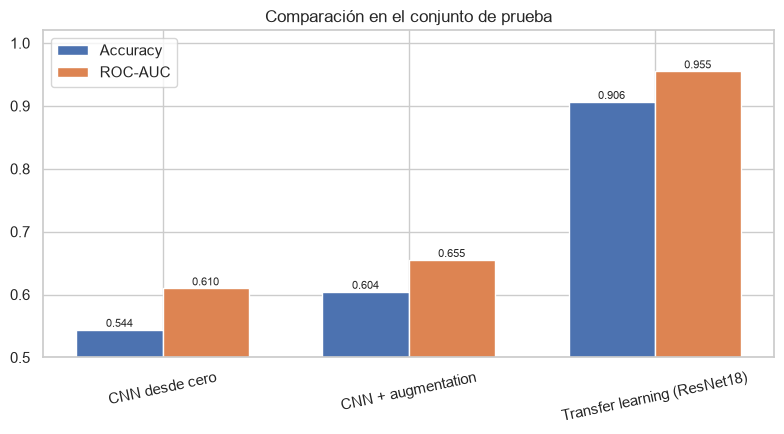

In [13]:
print("Resumen de resultados en test (149 imágenes)")
for k, (a, u) in RES.items():
    print(f"{k:32s} | acc={a:.4f} | auc={u:.4f}")
nombres = list(RES.keys()); accs = [RES[k][0] for k in nombres]; aucs = [RES[k][1] for k in nombres]
x = np.arange(len(nombres)); w = 0.35
plt.figure(figsize=(8, 4.5))
plt.bar(x - w/2, accs, w, label="Accuracy"); plt.bar(x + w/2, aucs, w, label="ROC-AUC")
plt.xticks(x, nombres, rotation=12); plt.ylim(0.5, 1.02); plt.legend(); plt.title("Comparación en el conjunto de prueba")
for i, (a, u) in enumerate(zip(accs, aucs)):
    plt.text(i - w/2, a + 0.005, f"{a:.3f}", ha="center", fontsize=8); plt.text(i + w/2, u + 0.005, f"{u:.3f}", ha="center", fontsize=8)
plt.tight_layout(); guardar("04_comparacion_cnn"); plt.show()

## 1.7 Grad-CAM
Mapa de calor de la última capa convolucional (`layer4`) de la ResNet18, para ver en qué zona de la imagen se apoya el modelo.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31912\1532755688.py:9: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  model.zero_grad(); logits[0, target_class].backward()


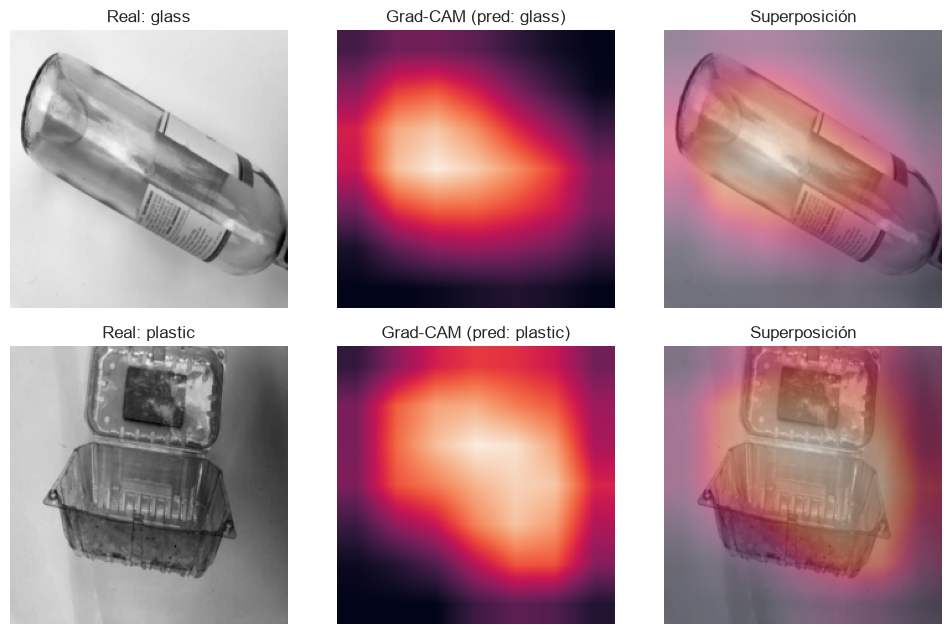

In [14]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    acts, grads = {}, {}
    h1 = model.layer4.register_forward_hook(lambda m, i, o: acts.__setitem__("v", o))
    h2 = model.layer4.register_full_backward_hook(lambda m, gi, go: grads.__setitem__("v", go[0]))
    logits = model(image_tensor.unsqueeze(0).to(device))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1))
    model.zero_grad(); logits[0, target_class].backward()
    w = grads["v"][0].mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * acts["v"][0]).sum(0))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    h1.remove(); h2.remove()
    return cam.detach().cpu().numpy(), target_class

test_ds_tl = TrashDataset(DATA_DIR, "test", tl_eval)
# Un ejemplo de cada clase (el primero de cada una en el conjunto de prueba)
idxs = [next(i for i, (_, l) in enumerate(test_ds_tl.samples) if l == c) for c in (0, 1)]
fig, ax = plt.subplots(2, 3, figsize=(10, 6.5))
for r, idx in enumerate(idxs):
    x, y = test_ds_tl[idx]
    cam, pred = grad_cam(resnet, x)
    cam_up = torch.nn.functional.interpolate(torch.tensor(cam)[None, None], size=(224, 224), mode="bilinear")[0, 0].numpy()
    img = x[0].numpy()
    ax[r, 0].imshow(img, cmap="gray"); ax[r, 0].set_title(f"Real: {TrashDataset.classes[int(y)]}")
    ax[r, 1].imshow(cam_up); ax[r, 1].set_title(f"Grad-CAM (pred: {TrashDataset.classes[pred]})")
    ax[r, 2].imshow(img, cmap="gray"); ax[r, 2].imshow(cam_up, alpha=0.5); ax[r, 2].set_title("Superposición")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); guardar("06_gradcam"); plt.show()

# Parte 2. Keras: clasificación binaria (IMDB) y red densa (MNIST)

## 2.1 IMDB: reseñas positivas o negativas
25 000 reseñas de entrenamiento y 25 000 de prueba, codificadas con las 10 000 palabras más frecuentes y convertidas a vectores one-hot de 10 000 posiciones [2]. Se reserva el primer bloque de 10 000 de entrenamiento como validación.

In [15]:
import keras
from keras import models as kmodels, layers, regularizers
from keras.datasets import imdb
keras.utils.set_random_seed(SEED)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)
print(len(train_data), len(test_data), "| etiquetas del entrenamiento (0=neg, 1=pos):", np.bincount(train_labels))

def vectorizar(secuencias, dim=10000):
    r = np.zeros((len(secuencias), dim), dtype="float32")
    for i, s in enumerate(secuencias):
        r[i, s] = 1.0
    return r
x_train, x_test = vectorizar(train_data), vectorizar(test_data)
y_train, y_test = train_labels.astype("float32"), test_labels.astype("float32")
x_val, partial_x_train = x_train[:10000], x_train[10000:]
y_val, partial_y_train = y_train[:10000], y_train[10000:]
print(partial_x_train.shape, x_val.shape, x_test.shape)

25000 25000 | etiquetas del entrenamiento (0=neg, 1=pos): [12500 12500]


(15000, 10000) (10000, 10000) (25000, 10000)


In [16]:
def modelo_imdb(units=16, l2=None, dropout=0.0):
    reg = regularizers.l2(l2) if l2 else None
    m = kmodels.Sequential([layers.Input(shape=(10000,))])
    for _ in range(2):
        m.add(layers.Dense(units, activation="relu", kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return m

KR = {}
configs = {"Base (16-16)": dict(), "Pequeño (4-4)": dict(units=4), "L2 (0.001)": dict(l2=0.001), "Dropout (0.5)": dict(dropout=0.5)}
HIST = {}
for nombre, cfg in configs.items():
    keras.utils.set_random_seed(SEED)
    m = modelo_imdb(**cfg)
    h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=0)
    loss, acc = m.evaluate(x_test, y_test, verbose=0)
    HIST[nombre] = h.history; KR[nombre] = (loss, acc)
    vl = np.array(h.history["val_loss"])
    print(f"{nombre:14s} | mejor val_loss={vl.min():.4f} en época {vl.argmin()+1} | val_loss final={vl[-1]:.4f} | "
          f"acc entrenamiento final={h.history['accuracy'][-1]:.4f} | acc val final={h.history['val_accuracy'][-1]:.4f} | test loss={loss:.4f} test acc={acc:.4f}")
    if nombre.startswith("Base"):
        modelo_base = m

Base (16-16)   | mejor val_loss=0.2784 en época 5 | val_loss final=0.5450 | acc entrenamiento final=0.9965 | acc val final=0.8698 | test loss=0.5881 test acc=0.8577


Pequeño (4-4)  | mejor val_loss=0.2745 en época 10 | val_loss final=0.3329 | acc entrenamiento final=0.9831 | acc val final=0.8819 | test loss=0.3581 test acc=0.8704


L2 (0.001)     | mejor val_loss=0.3322 en época 5 | val_loss final=0.4337 | acc entrenamiento final=0.9721 | acc val final=0.8753 | test loss=0.4572 test acc=0.8634


Dropout (0.5)  | mejor val_loss=0.2925 en época 7 | val_loss final=0.5131 | acc entrenamiento final=0.9745 | acc val final=0.8834 | test loss=0.5415 test acc=0.8742


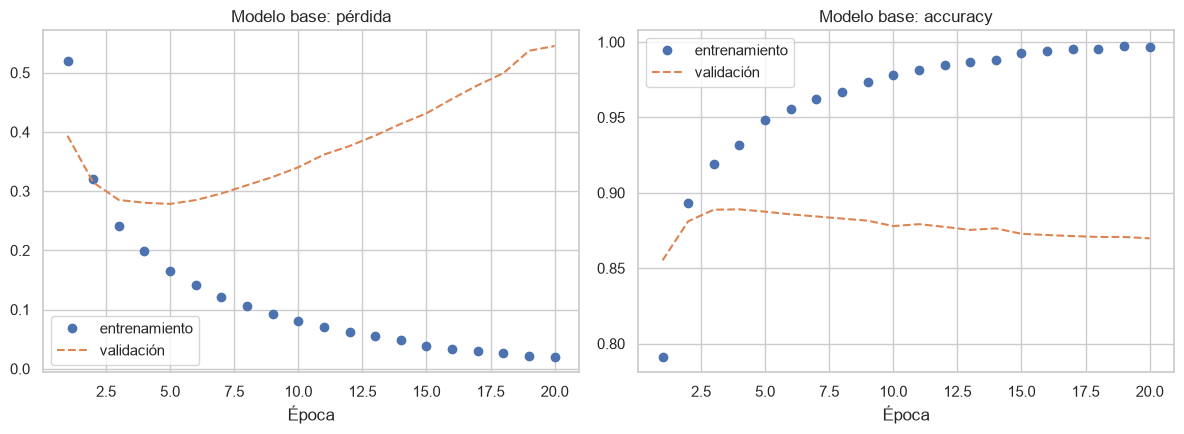

In [17]:
h = HIST["Base (16-16)"]; ep = range(1, 21)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(ep, h["loss"], "o", label="entrenamiento"); ax[0].plot(ep, h["val_loss"], "--", label="validación")
ax[0].set_title("Modelo base: pérdida"); ax[0].set_xlabel("Época"); ax[0].legend()
ax[1].plot(ep, h["accuracy"], "o", label="entrenamiento"); ax[1].plot(ep, h["val_accuracy"], "--", label="validación")
ax[1].set_title("Modelo base: accuracy"); ax[1].set_xlabel("Época"); ax[1].legend()
plt.tight_layout(); guardar("07_keras_base"); plt.show()

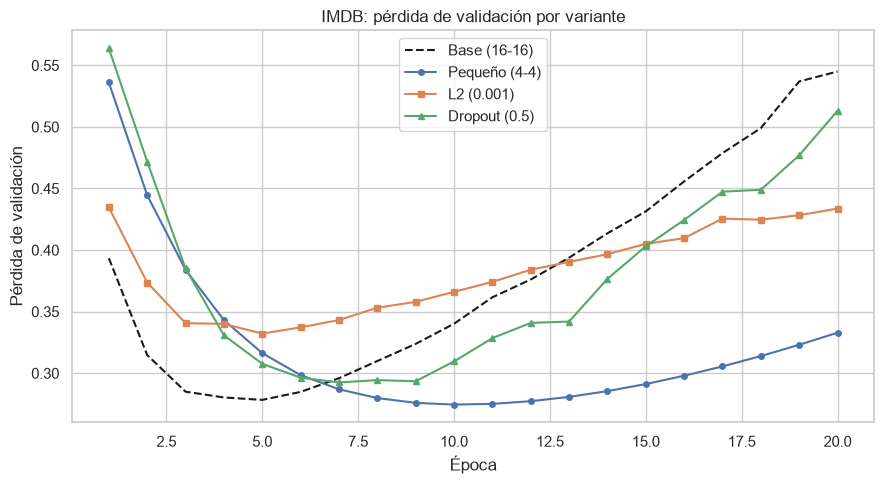

In [18]:
plt.figure(figsize=(9, 5))
for nombre, st in zip(HIST, ["k--", "o-", "s-", "^-"]):
    plt.plot(ep, HIST[nombre]["val_loss"], st, label=nombre, ms=4)
plt.xlabel("Época"); plt.ylabel("Pérdida de validación"); plt.title("IMDB: pérdida de validación por variante"); plt.legend()
plt.tight_layout(); guardar("08_keras_variantes"); plt.show()

In [19]:
pred = modelo_base.predict(x_test, verbose=0)
print("Predicción para la reseña 10: P(positiva) = %.4f | etiqueta real = %d" % (pred[10, 0], test_labels[10]))

Predicción para la reseña 10: P(positiva) = 0.9928 | etiqueta real = 1


## 2.2 MNIST: red densa multiclase
Una capa oculta de 512 neuronas ReLU y salida softmax de 10 clases, 5 épocas.

(60000, 28, 28) (10000, 28, 28)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Accuracy de entrenamiento por época: [0.9258, 0.9693, 0.9802, 0.9863, 0.9905]


MNIST test loss=0.0664 | test accuracy=0.9788


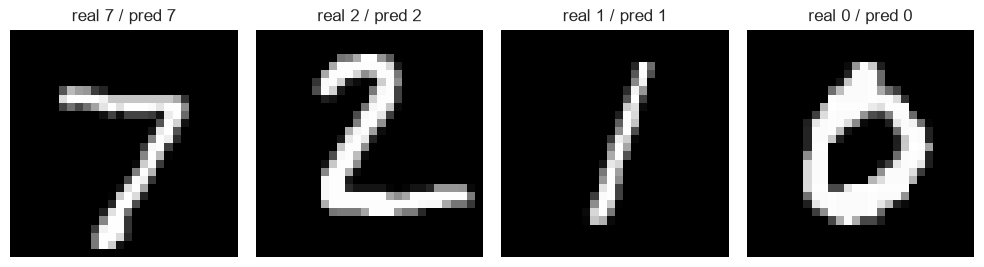

In [20]:
from keras.datasets import mnist
from keras.utils import to_categorical
(tr_d, tr_l), (te_d, te_l) = mnist.load_data()
print(tr_d.shape, te_d.shape)
xm_train = tr_d.reshape((60000, 784)).astype("float32") / 255
xm_test = te_d.reshape((10000, 784)).astype("float32") / 255
ym_train, ym_test = to_categorical(tr_l), to_categorical(te_l)
keras.utils.set_random_seed(SEED)
mnist_model = kmodels.Sequential([layers.Input(shape=(784,)), layers.Dense(512, activation="relu"), layers.Dense(10, activation="softmax")])
mnist_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
mnist_model.summary()
hm = mnist_model.fit(xm_train, ym_train, epochs=5, batch_size=128, verbose=0)
print("Accuracy de entrenamiento por época:", [round(a, 4) for a in hm.history["accuracy"]])
mloss, macc = mnist_model.evaluate(xm_test, ym_test, verbose=0)
print(f"MNIST test loss={mloss:.4f} | test accuracy={macc:.4f}")
fig, ax = plt.subplots(1, 4, figsize=(10, 3))
for i, a in enumerate(ax):
    a.imshow(te_d[i], cmap="gray"); a.axis("off")
    a.set_title(f"real {te_l[i]} / pred {mnist_model.predict(xm_test[i:i+1], verbose=0).argmax()}")
plt.tight_layout(); guardar("09_mnist_ejemplos"); plt.show()

# Parte 3. Perceptrón

## 3.1 Funciones de activación
El perceptrón calcula la suma ponderada de sus entradas más el sesgo y la pasa por una función de activación. Se comparan escalón y tanh con el ejemplo de clase (presión arterial 100, colesterol HDL 50, pesos 0.5 y -0.5, sesgo -30).

Suma ponderada z = -5.0
Salida con escalón: 0
Salida con tanh:    -0.9999092042625951


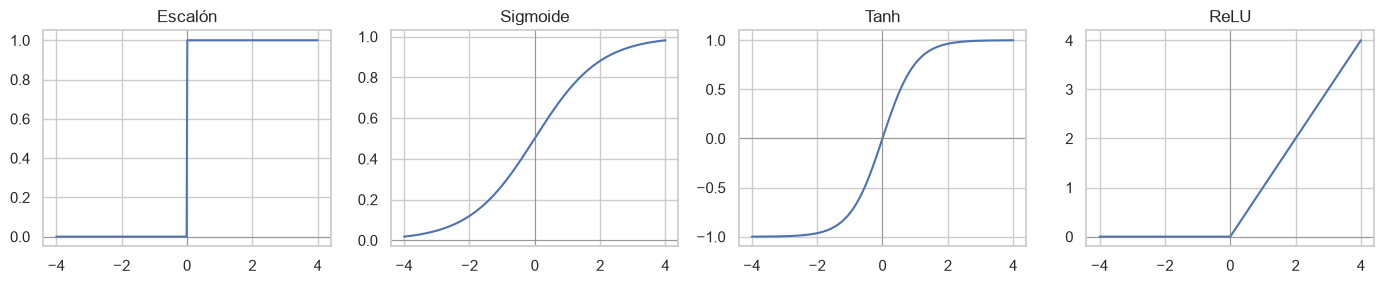

In [21]:
def step_function(x): return 1 if x >= 0 else 0
def tanh_activation(x): return np.tanh(x)
def perceptron(inputs, weights, bias, f): return f(np.dot(inputs, weights) + bias)

inputs = np.array([100, 50]); weights = np.array([0.5, -0.5]); bias = -30
z = np.dot(inputs, weights) + bias
print("Suma ponderada z =", z)
print("Salida con escalón:", perceptron(inputs, weights, bias, step_function))
print("Salida con tanh:   ", perceptron(inputs, weights, bias, tanh_activation))

zz = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(1, 4, figsize=(14, 3))
for a, (n, f) in zip(ax, [("Escalón", lambda v: (v >= 0).astype(float)), ("Sigmoide", lambda v: 1/(1+np.exp(-v))), ("Tanh", np.tanh), ("ReLU", lambda v: np.maximum(0, v))]):
    a.plot(zz, f(zz)); a.set_title(n); a.axhline(0, color="gray", lw=0.5); a.axvline(0, color="gray", lw=0.5)
plt.tight_layout(); guardar("10_activaciones"); plt.show()

## 3.2 Compuertas AND y OR
Un solo perceptrón con escalón, pesos y sesgo elegidos a mano.

In [22]:
entradas = [(0, 0), (0, 1), (1, 0), (1, 1)]
def tabla(nombre, w, b):
    sal = [perceptron(np.array(e), np.array(w), b, step_function) for e in entradas]
    print(f"{nombre}: pesos={w}, sesgo={b} -> salidas {sal}")
    return sal
and_ = tabla("AND", [0.4, 0.4], -0.5)
and_mal = tabla("Intento de AND de la clase (pesos 0.8 y 0.5, sesgo -0.7)", [0.8, 0.5], -0.7)
and2 = tabla("AND corregido (pesos 0.8 y 0.5, sesgo -1.0)", [0.8, 0.5], -1.0)
or_ = tabla("OR", [2, 1], -0.5)
print("¿El intento de la clase es un AND?", and_mal == [0, 0, 0, 1], "(da [0, 0, 1, 1]: dispara con (1,0) porque 0.8 - 0.7 = 0.1 >= 0)")
assert and_ == [0, 0, 0, 1] and and2 == [0, 0, 0, 1] and or_ == [0, 1, 1, 1]
xor_1 = tabla("XOR con un perceptrón (w=[1,1], b=-0.5)", [1, 1], -0.5)
print("¿Coincide con XOR [0,1,1,0]?", xor_1 == [0, 1, 1, 0])

AND: pesos=[0.4, 0.4], sesgo=-0.5 -> salidas [0, 0, 0, 1]
Intento de AND de la clase (pesos 0.8 y 0.5, sesgo -0.7): pesos=[0.8, 0.5], sesgo=-0.7 -> salidas [0, 0, 1, 1]
AND corregido (pesos 0.8 y 0.5, sesgo -1.0): pesos=[0.8, 0.5], sesgo=-1.0 -> salidas [0, 0, 0, 1]
OR: pesos=[2, 1], sesgo=-0.5 -> salidas [0, 1, 1, 1]
¿El intento de la clase es un AND? False (da [0, 0, 1, 1]: dispara con (1,0) porque 0.8 - 0.7 = 0.1 >= 0)
XOR con un perceptrón (w=[1,1], b=-0.5): pesos=[1, 1], sesgo=-0.5 -> salidas [0, 1, 1, 1]
¿Coincide con XOR [0,1,1,0]? False


## 3.3 XOR: por qué un solo perceptrón no alcanza
Una sola neurona separa el plano con una recta, y XOR no es linealmente separable. Para comprobarlo, busco con una malla fina de pesos y sesgos si alguna combinación de una neurona reproduce XOR.

In [23]:
import itertools
grid = np.linspace(-3, 3, 61)
encontrados = 0
for w1, w2, b in itertools.product(grid, grid, grid):
    sal = [1 if w1*p + w2*q + b >= 0 else 0 for p, q in entradas]
    if sal == [0, 1, 1, 0]:
        encontrados += 1
print("Combinaciones probadas:", len(grid)**3, "| combinaciones que dan XOR con una sola neurona:", encontrados)

Combinaciones probadas: 226981 | combinaciones que dan XOR con una sola neurona: 0


XOR con 2 capas: [0, 1, 1, 0] | correcto: True


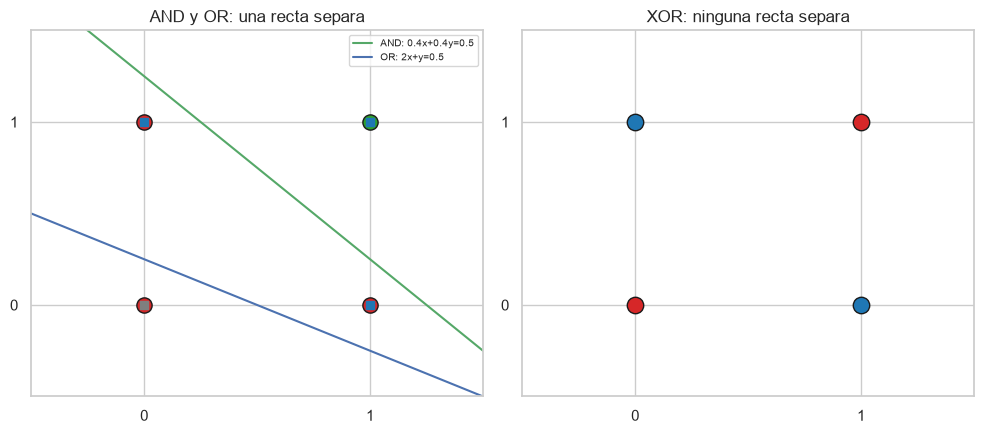

In [24]:
# Con dos capas sí se puede: h1 = OR(x, y), h2 = NAND(x, y), salida = AND(h1, h2)
def xor_dos_capas(p, q):
    h1 = perceptron(np.array([p, q]), np.array([1, 1]), -0.5, step_function)     # OR
    h2 = perceptron(np.array([p, q]), np.array([-1, -1]), 1.5, step_function)    # NAND
    return perceptron(np.array([h1, h2]), np.array([1, 1]), -1.5, step_function) # AND
sal = [xor_dos_capas(p, q) for p, q in entradas]
print("XOR con 2 capas:", sal, "| correcto:", sal == [0, 1, 1, 0])

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
for a, titulo in zip(ax, ["AND y OR: una recta separa", "XOR: ninguna recta separa"]):
    a.set_xlim(-0.5, 1.5); a.set_ylim(-0.5, 1.5); a.set_xticks([0, 1]); a.set_yticks([0, 1]); a.set_title(titulo)
for (p, q), sa, so, sx in zip(entradas, and_, or_, [0, 1, 1, 0]):
    ax[0].scatter(p, q, c="tab:green" if sa else "tab:red", s=120, marker="o", edgecolor="k")
    ax[0].scatter(p, q, c="tab:blue" if so else "tab:gray", s=40, marker="s")
    ax[1].scatter(p, q, c="tab:blue" if sx else "tab:red", s=140, edgecolor="k")
xs = np.linspace(-0.5, 1.5, 10)
ax[0].plot(xs, 1.25 - xs, "g-", label="AND: 0.4x+0.4y=0.5"); ax[0].plot(xs, 0.25 - xs/2, "b-", label="OR: 2x+y=0.5"); ax[0].legend(fontsize=7)
plt.tight_layout(); guardar("11_perceptron_and_or_xor"); plt.show()

In [25]:
print("=== RESUMEN DE RESULTADOS ===")
print("CNN (TrashNet, test, 149 imágenes):")
for k, (a, u) in RES.items(): print(f"  {k:30s} acc={a:.4f}  auc={u:.4f}")
print("Keras IMDB (test, 25 000 reseñas):")
for k, (l, a) in KR.items(): print(f"  {k:30s} loss={l:.4f}  acc={a:.4f}")
print(f"Keras MNIST (test): acc={macc:.4f}")

=== RESUMEN DE RESULTADOS ===
CNN (TrashNet, test, 149 imágenes):
  CNN desde cero                 acc=0.5436  auc=0.6096
  CNN + augmentation             acc=0.6040  auc=0.6547
  Transfer learning (ResNet18)   acc=0.9060  auc=0.9548
Keras IMDB (test, 25 000 reseñas):
  Base (16-16)                   loss=0.5881  acc=0.8577
  Pequeño (4-4)                  loss=0.3581  acc=0.8704
  L2 (0.001)                     loss=0.4572  acc=0.8634
  Dropout (0.5)                  loss=0.5415  acc=0.8742
Keras MNIST (test): acc=0.9788
